In [1]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter
from scipy.sparse.linalg import gmres

In [2]:
# data (solution is phi_0 of TC_Matthieu)
rho = 0.25
sigma_in = 0.1
sigma_ex = 1
phi_datum = lambda x,y: 1.0 # first interface data
                            # second interface data (0)

# ref sol: expressions in x,y 
ref_sol_in = lambda x,y: 2*sigma_ex/(sigma_ex+sigma_in)*x -1
ref_sol_ex = lambda x,y: x*( 1+ (sigma_ex-sigma_in)/(sigma_ex+sigma_in)*(rho)**2/(x**2+y**2))

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          rho=rho, ref_sol_in=ref_sol_in, ref_sol_ex=ref_sol_ex: \
          ddr.reference_solution(mesh, dof, rho, ref_sol_in, ref_sol_ex) 

                            # source term (0)
eta = 100                     # stability parameter

In [3]:
mesh = ddr.load_square_mesh("square_L1_N10.msh")

In [4]:
def move_critical_points(mesh, rho, N):
    for ino in range(mesh.Npoints_init):
        x = mesh.coords[ino,0]
        y = mesh.coords[ino,1]
        radius = np.sqrt(x**2+y**2)
        cos_theta = x/radius
        sin_theta = y/radius
        # If node is close to interface less than 1/10*mesh_size
        if (np.abs(rho-radius)<0.1*(1/N)):
            # internal nodes towards interior
            if (radius<rho):
                new_radius = radius - 0.1*(1/N)
            if (radius>rho):
                new_radius = radius + 0.1*(1/N)
            new_x = new_radius*cos_theta
            new_y = new_radius*sin_theta             
            mesh.coords[ino,0] = new_x
            mesh.coords[ino,1] = new_y
move_critical_points(mesh,rho,20)
ddr.break_mesh(mesh, rho)

### Definition based on direct values and not on reconstruction

In [5]:
def assemble_M_gamma(mesh,sigma_in,sigma_ex):
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    
    for ied in range(len(mesh.gamma_edges)):
        # table of dofs touched by the edge
        # 7 dofs: 3 from the triangle + 4 from the quad
        edge_dofs = np.zeros((7,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
        for idof1 in range(7):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face$
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            tangent = mesh.coords[mesh.faces[ifa1,1],0:2]-mesh.coords[mesh.faces[ifa1,0],0:2]
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)
            normal = sign1*np.array([[0,1],[-1,0]])@tangent
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc], normal)
            
            dof_intf_in_1 = ddr.glob_idx(mesh, ifa_in, 0)
            dof_intf_in_2 = ddr.glob_idx(mesh, ifa_in, 1)
            dof_intf_ex_1 = ddr.glob_idx(mesh, ifa_ex, 0)
            dof_intf_ex_2 = ddr.glob_idx(mesh, ifa_ex, 1)
 
            M_gamma[dof1,dof_intf_in_1] = M_gamma[dof1,dof_intf_in_1] - mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_in_2] = M_gamma[dof1,dof_intf_in_2] - mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_ex_1] = M_gamma[dof1,dof_intf_ex_1] + mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_ex_2] = M_gamma[dof1,dof_intf_ex_2] + mean_sigma_grad_normal*0.5
            
    return M_gamma         

M_gamma = assemble_M_gamma(mesh, sigma_in ,sigma_ex)

In [6]:
# function to create connectivity bnd_edge2[node1,node2]
def create_bnd_connectivity(mesh):
    bnd_edges = []
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            for ie in range(node_per_face):
                ino1 = mesh.faces[ifa,ie] # should be counter clockwise
                ino2 = mesh.faces[ifa,(ie+1)%node_per_face]
                if (mesh.bnd_mask[ino1]>0 and mesh.bnd_mask[ino2]>0):
                    edge = np.array([ifa,ie,(ie+1)%node_per_face]) # record face and 2 local dofs
                    bnd_edges.append(edge)
    return bnd_edges

def assemble_FLUX_bnd(mesh, bnd_edges, sigma_min, sigma_plus, visualize):
    if (visualize): 
        fig, ax = plt.subplots(figsize=(20,20))
    to_check = 5
    # visualize underlying mesh
    #################################################################
    if (visualize):
        for ifa in range(mesh.Nfaces):
            if (mesh.cut_faces[ifa]!=1):
                nvert = np.count_nonzero(mesh.faces[ifa,:] != -1)
                for ino in range(nvert):
                    p1 = mesh.coords[mesh.faces[ifa,ino],:]
                    glob_ino = mesh.faces[ifa,(ino+1)%nvert]
                    p2 = mesh.coords[glob_ino,:]
                    dx = p2-p1
                    xx = [p1[0],p2[0]]
                    yy = [p1[1],p2[1]]
                    ax.plot(xx,yy,'k', linewidth=0.1)
    ##################################################################
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa, locdof1] # index of node
        ino2 = mesh.faces[ifa, locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        # fluxes of test functions
        G = ddr.GR(mesh, ifa)
        tangent = p2 - p1
        normal = np.array([[0,1],[-1,0]])@tangent[0:2]
        # sigma
        sigma = sigma_plus # -----------------> internal interface
        ###############################################################
        # visualize normal (suppressed section)
        if (visualize):
            midpoint = 0.5*(p1+p2)
            ax.plot((p1[0], p2[0]), (p1[1], p2[1]))
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
        ###############################################################
        node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
        # loop over all dofs of elements
        for locdof in range(node_per_face):
            idof = ddr.glob_idx(mesh, ifa, locdof) # global dof
            flux = sigma*np.dot(G[:,locdof], normal)
            if (visualize):
                normal = normal/np.linalg.norm(normal)*flux/10
                ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1], color = "red")
            DIR[idof1,idof] = DIR[idof1,idof] + flux*0.5
            DIR[idof2,idof] = DIR[idof2,idof] + flux*0.5
    return DIR

# function to assemble DIR matrix
def assemble_DIR_matrix(mesh, bnd_edges):
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa,locdof1] # index of node
        ino2 = mesh.faces[ifa,locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        DIR[idof1,idof1] = DIR[idof1,idof1] + ddr.calc_r2_prod_integ(v1A,v1B,v1A,v1B) # notice, it's symmetric
        DIR[idof1,idof2] = DIR[idof1,idof2] + ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
        DIR[idof2,idof1] = DIR[idof2,idof1] + ddr.calc_r2_prod_integ(v2A,v2B,v1A,v1B)
        DIR[idof2,idof2] = DIR[idof2,idof2] + ddr.calc_r2_prod_integ(v2A,v2B,v2A,v2B)
    return DIR

# function to assemble b_g vector
def assemble_b_dir(mesh, bnd_edges, ref_sol):
    b_dir = np.zeros(mesh.Ndof)
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # local dof
        locdof2 = bnd_edges[ie][2]
        ino1  = mesh.faces[ifa,locdof1] # index of node
        ino2  = mesh.faces[ifa,locdof2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2]
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        gA = ref_sol(mesh, idof1)
        gB = ref_sol(mesh, idof2)
        b_dir[idof1] = b_dir[idof1] + ddr.calc_r2_prod_integ(v1A,v1B,gA,gB) # notice, it's symmetric
        b_dir[idof2] = b_dir[idof2] + ddr.calc_r2_prod_integ(v2A,v2B,gA,gB)
    return b_dir

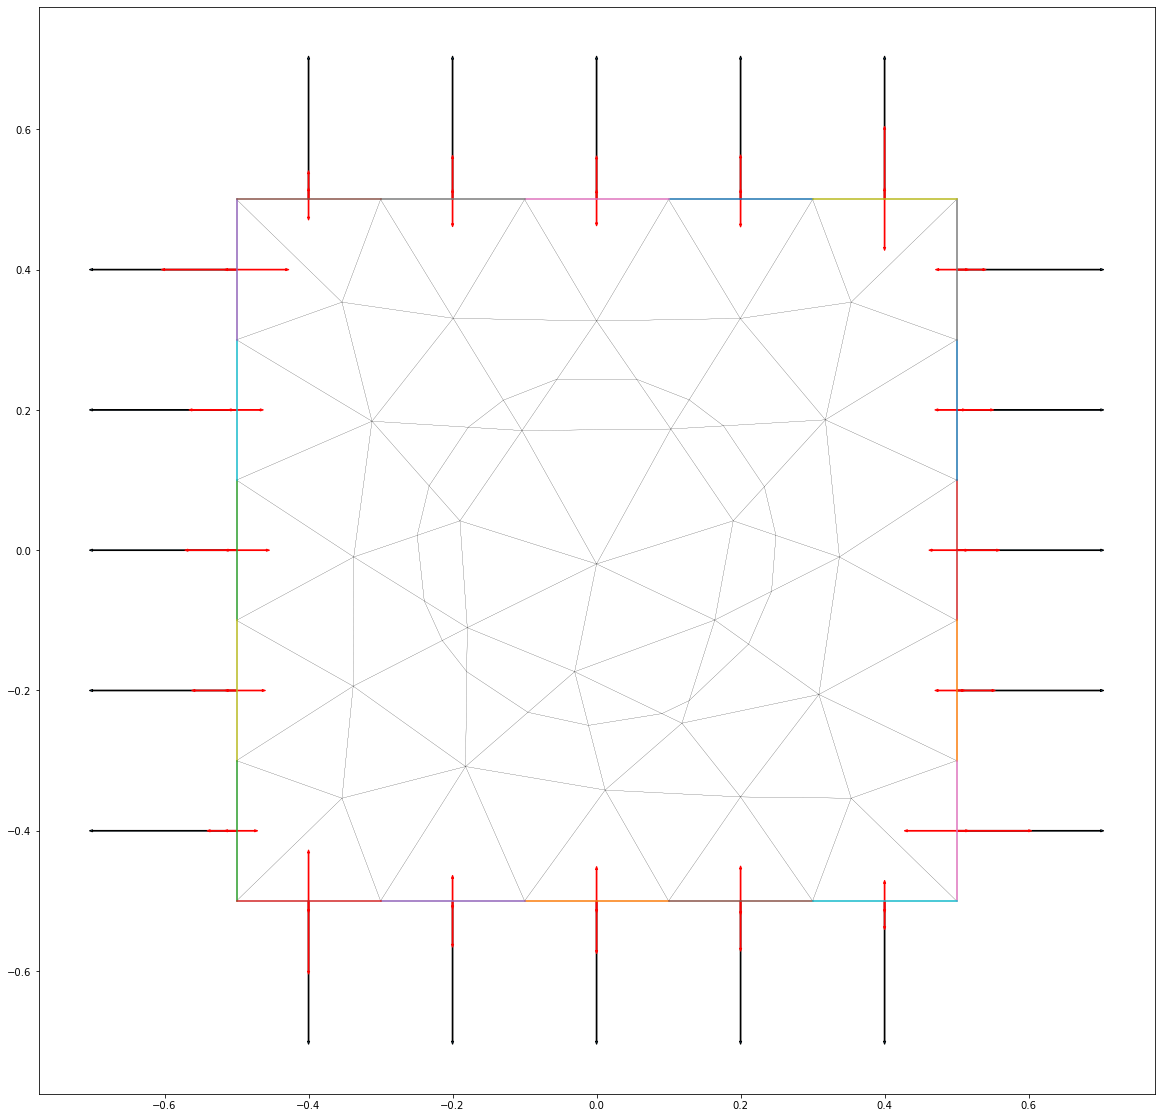

In [7]:
mesh_filename = "square_L1_N5.msh"
mesh = ddr.load_square_mesh(mesh_filename)
# move critical points near the interface
ddr.move_critical_points(mesh, rho)
# break mesh
ddr.break_mesh(mesh, rho) 
# mark boundaries
mesh.bnd_mask = np.zeros(mesh.Npoints) # have to increase size of bnd_mask
ddr.mark_bnd_points(mesh)    
bnd_edges = create_bnd_connectivity(mesh)
FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_in, sigma_ex, visualize = True)

In [8]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
FLUX_bnd_matrices = []
DIR_matrices = []
b_dir_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

tolerance = 1e-20 # imposed tolerance for linear solver
eta = 1

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i])
    # move critical points near the interface
    ddr.move_critical_points(mesh, rho)
    # break mesh
    ddr.break_mesh(mesh, rho) 
    # mark boundaries
    mesh.bnd_mask = np.zeros(mesh.Npoints) # have to increase size of bnd_mask
    ddr.mark_bnd_points(mesh)    
    bnd_edges = create_bnd_connectivity(mesh)
    # assemble system
    G = ddr.assemble_G(mesh, sigma_in,sigma_ex) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    #M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    M_gamma = assemble_M_gamma(mesh,sigma_in,sigma_ex) # --------> adapted version
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    DIR = assemble_DIR_matrix (mesh, bnd_edges)
    b_dir = assemble_b_dir (mesh, bnd_edges, ref_sol)
    FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_in, sigma_ex, visualize = False)
    # define system, apply bc conds an solve
    A = G+S+eta*N_gamma+np.transpose(M_gamma) 
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    #u = np.linalg.solve(A, b)
    [N_gamma, b_gamma] = ddr.impose_bc(mesh, N_gamma, b_phi, ref_sol)
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "G+M_Gamma-FLUX_bnd ", np.max( np.abs( np.dot( G+np.transpose(M_gamma)-FLUX_bnd, u ) ) ), \
                          "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma ", np.max(np.abs(np.dot(N_gamma,u)-b_gamma)), \
                          "DIR", np.max(np.abs(np.dot(DIR,u)-b_dir)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)))
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    FLUX_bnd_matrices.append(FLUX_bnd)
    DIR_matrices.append(DIR)
    b_dir_vectors.append(b_dir)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

Residuals:  G+M_Gamma-FLUX_bnd  0.021117428362764618 S  0.016116601457492344 N_gamma  0.011426330293360293 DIR 1.3877787807814457e-17 total  5.551115123125783e-16
Residuals:  G+M_Gamma-FLUX_bnd  0.007135415594735146 S  0.006997218025382994 N_gamma  0.004923376881277919 DIR 1.1102230246251565e-16 total  6.661338147750939e-16
Residuals:  G+M_Gamma-FLUX_bnd  0.003465304180162887 S  0.00280190157641233 N_gamma  0.001494046783161316 DIR 2.220446049250313e-16 total  2.1094237467877974e-15
Residuals:  G+M_Gamma-FLUX_bnd  0.0009229837380877459 S  0.000779687840962523 N_gamma  0.0003630964662925777 DIR 2.220446049250313e-16 total  1.6653345369377348e-15


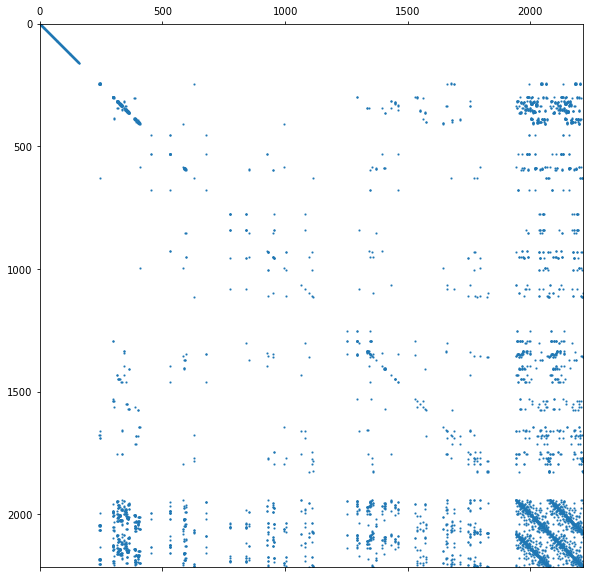

In [9]:
ax,fig = plt.subplots(figsize=(10,10))
plt.spy(N_gamma, markersize=1)

### Calculate Residuals at $u_{ex}$ 

In [10]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]
N_gamma = N_gamma_matrices[n]
DIR = DIR_matrices[n]
b_dir = b_dir_vectors[n]
S = S_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
b = b_vectors[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nG+M_Gamma-FLUX_bnd ", np.max( np.abs( np.dot( G+np.transpose(M_gamma)-FLUX_bnd, u_ref ) ) ), \
                     "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\n(M_gamma ", np.max(np.abs(np.dot(M_gamma,u_ref))),")" \
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\nDIR", np.max(np.abs(np.dot(DIR,u_ref)-b_dir)), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))

Residuals: 
G+M_Gamma-FLUX_bnd  0.0378003590745932 
S  0.013908005160041698 
(M_gamma  1.613065557975155 )
N_gamma  0.00027418690295542836 
DIR 1.3877787807814457e-17 
total  0.029494531037433047


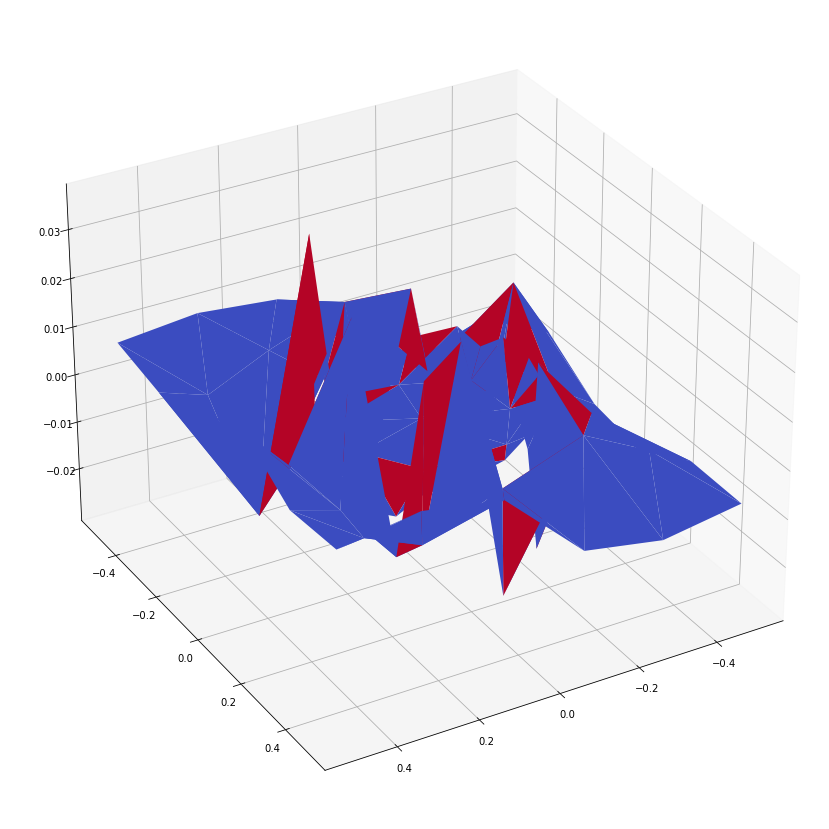

In [11]:
n = 0
mesh = Meshes[n]
G = G_matrices[n]
S = S_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]

A = G +np.transpose(M_gamma)-FLUX_bnd

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(Meshes[n], np.dot(A,u_ref), elevation=30, azimuth=60)

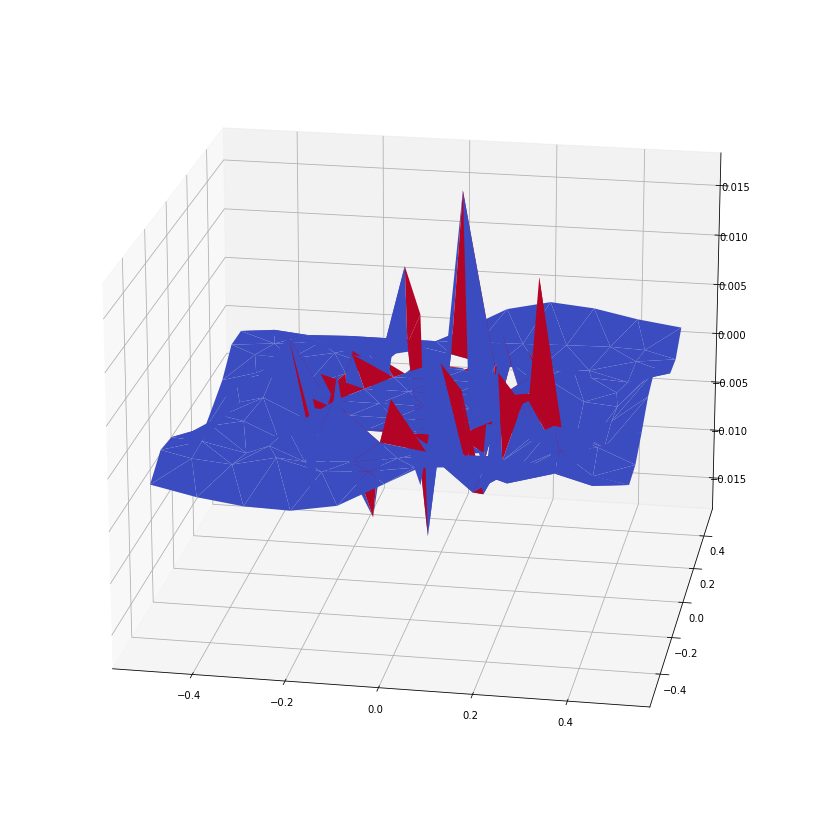

In [14]:
# CHECK GRADIENT (without boundary flux)
n = 1
mesh = Meshes[n]
G = G_matrices[n] 
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(G+np.transpose(M_gamma)-FLUX_bnd,u_ref), elevation=20, azimuth=-80)

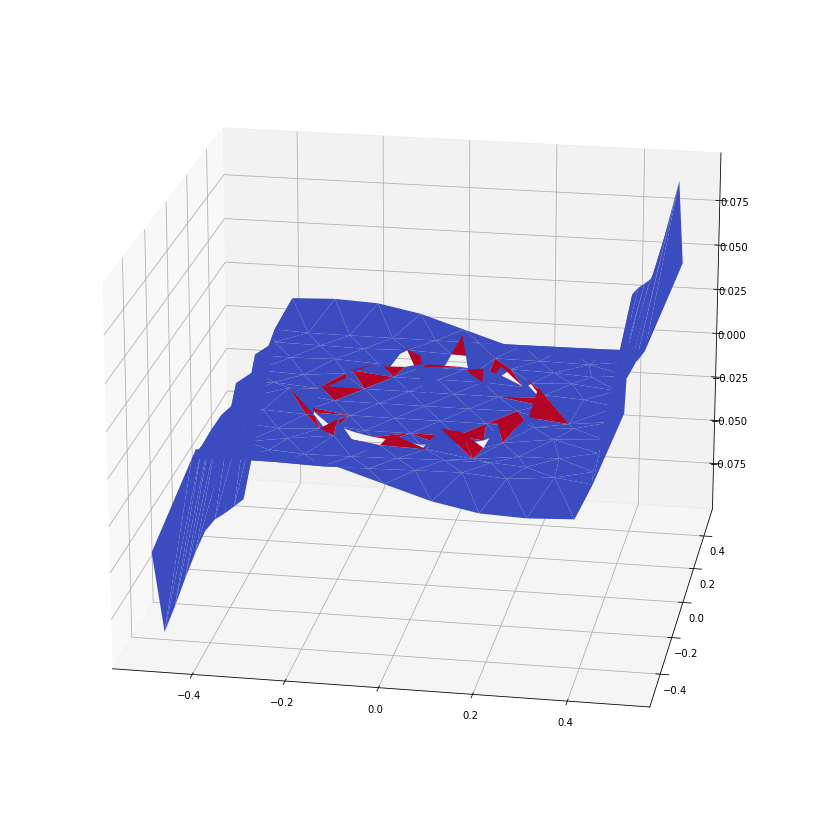

In [15]:
# CHECK G+M (without boundary flux)
n = 1
mesh = Meshes[n]
G = G_matrices[n] 
M_gamma = M_gamma_matrices[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(G+np.transpose(M_gamma),u_ref), elevation=20, azimuth=-80)

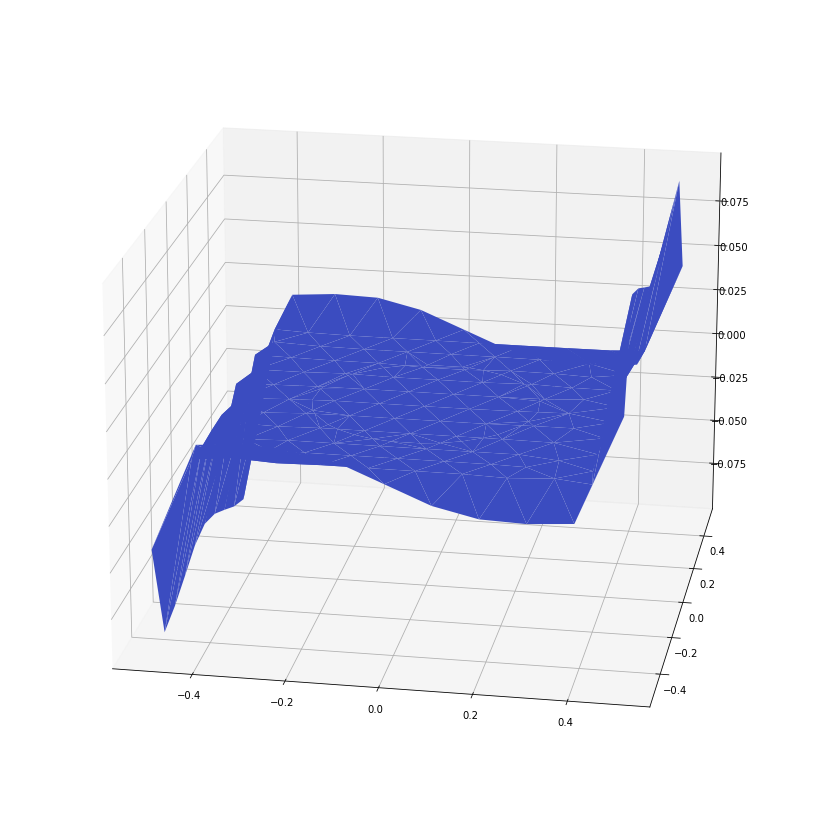

In [12]:
# CHECK G+M (without boundary flux)
n = 1
mesh = Meshes[n]
FLUX_bnd = FLUX_bnd_matrices[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(FLUX_bnd,u_ref), elevation=20, azimuth=-80)

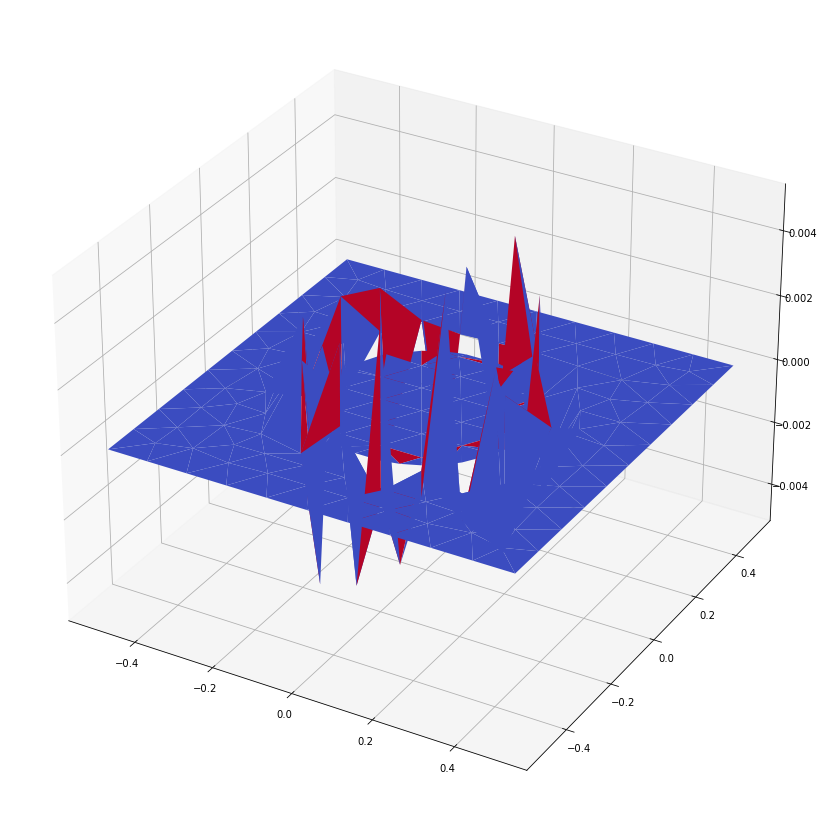

In [13]:
# CHECK POTENTIAL RECONSTRUCTION 
n = 1
mesh = Meshes[n]
S = S_matrices[n]       
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(S,u_ref), elevation=30, azimuth=-60)

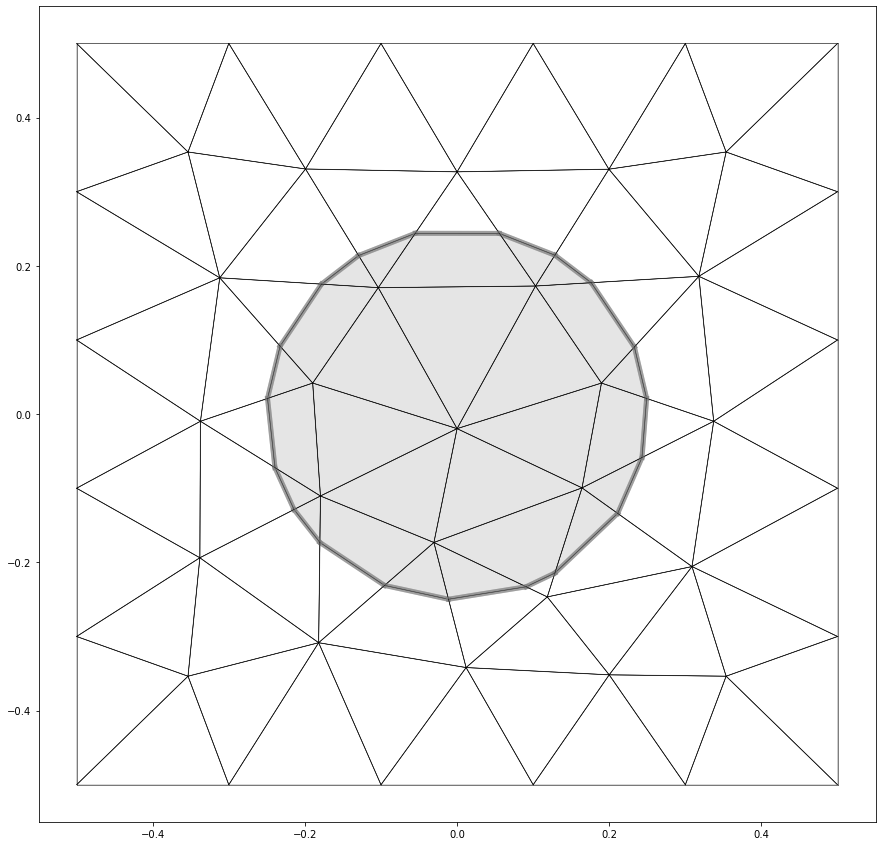

In [36]:
n = 0

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(15,15))
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.5)
               if (mesh.faces[ifa,ino]>= mesh.Npoints_init and mesh.faces[ifa,(ino+1)%nvert]>= mesh.Npoints_init ): 
                   ax.plot(xx,yy,'gray', linewidth=5.0, alpha = 0.5)
               verts.append(p1[0:2])
            if (np.linalg.norm(ddr.barycenter (mesh, ifa))<0.25):
                color = 'gray'
            else:
                color = 'white'
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
                

# mark generated points
#    for dof in range(mesh.Npoints):
#       if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            xx = mesh.coords[ino,0]
#            yy = mesh.coords[ino,1]
#            if (mesh.bnd_mask[ino]==1):
#                point = ax.scatter(xx,yy,color='green')
#            if (mesh.bnd_mask[ino]==2):
#                point = ax.scatter(xx,yy,color='blue')
#            if (mesh.bnd_mask[ino]==3):
#                point = ax.scatter(xx,yy,color='red')
#            if (mesh.bnd_mask[ino]==4):
#                point = ax.scatter(xx,yy,color='yellow')

    
visualize_bnd_points_with_dof(mesh)        

simple look at the mesh (to make a picture for the article)

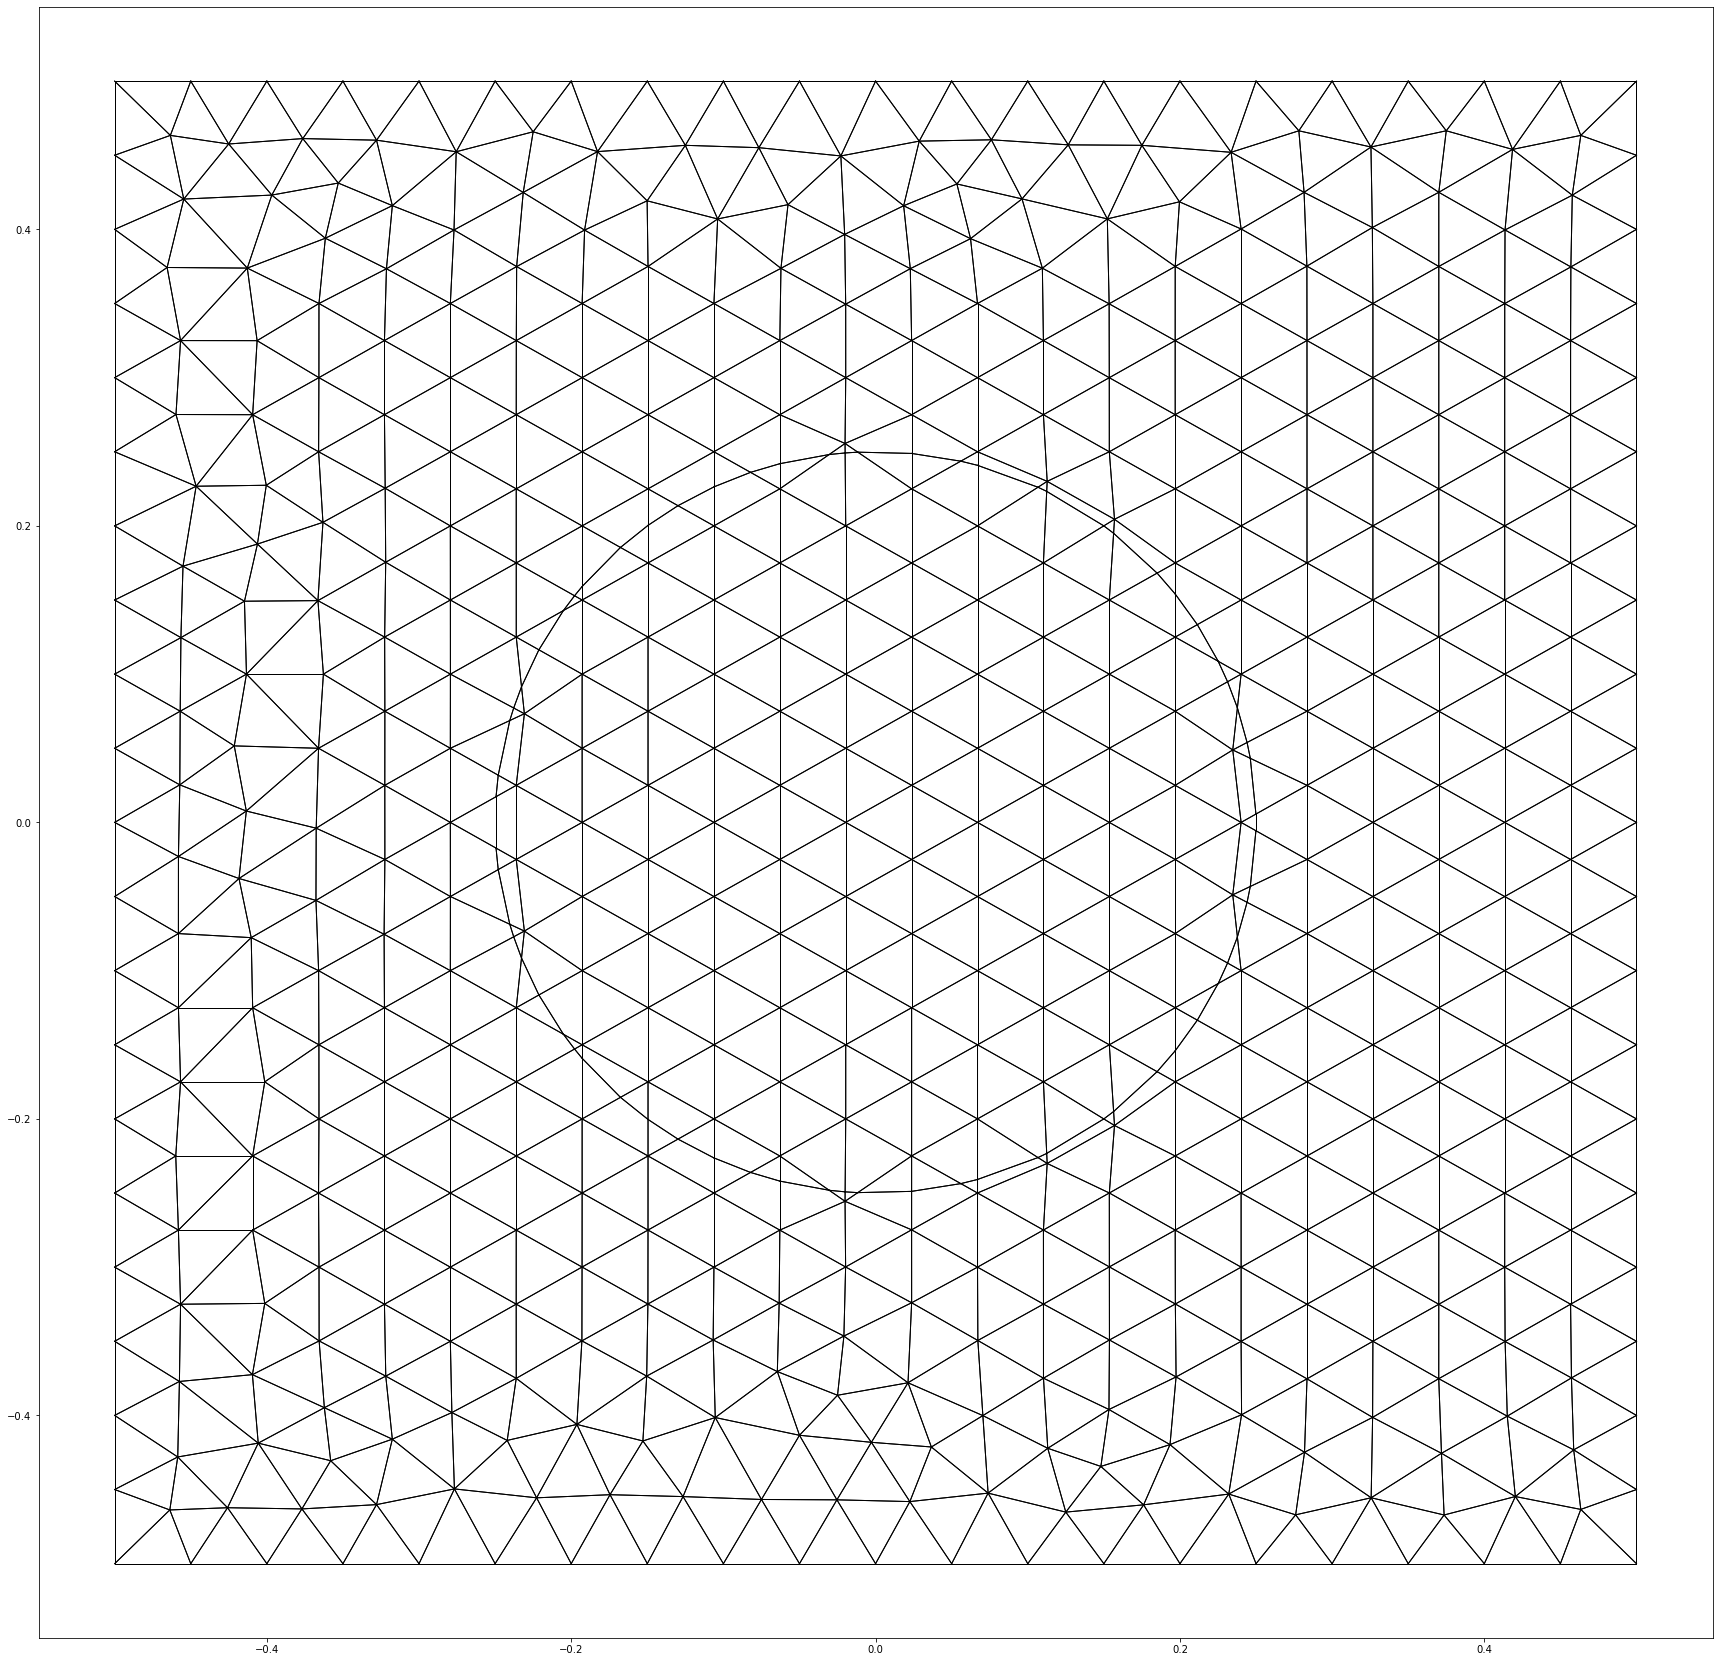

In [19]:
mesh_filename = "square_L1_N20.msh"
mesh = ddr.load_square_mesh(mesh_filename)
# move critical points near the interface
ddr.move_critical_points(mesh, rho)
# break mesh
ddr.break_mesh(mesh, rho) 


def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(30,30))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=1)


    
visualize_bnd_points_with_dof(mesh)
plt.savefig("cut_mesh.svg", format='svg', dpi = 300)

In [5]:
# solve for a given mesh 
meshname = "square_L1_N10"
#meshname = "/home/aspadotto/meshes/square"
[mesh, G, G_no_sigma, S, M_gamma, N_gamma, b_phi, A, b, u, err] = \
        ddr.solve_problem(meshname+".msh", meshname+".vtk", \
                          rho, ref_sol, sigma_in, sigma_ex, eta, phi_datum)

In [5]:
def calc_energy_error (mesh, u, ref_sol, G_no_sigma, N_gamma, S):
    u_ref = np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)])
    err = u - u_ref
    contrib_1 = np.dot(np.dot(G_no_sigma,err),err)
    contrib_2 = np.dot(np.dot(N_gamma,err),err)
    contrib_3 = np.dot(np.dot(S,err),err)
    return np.sqrt(contrib_1+contrib_2+contrib_3)

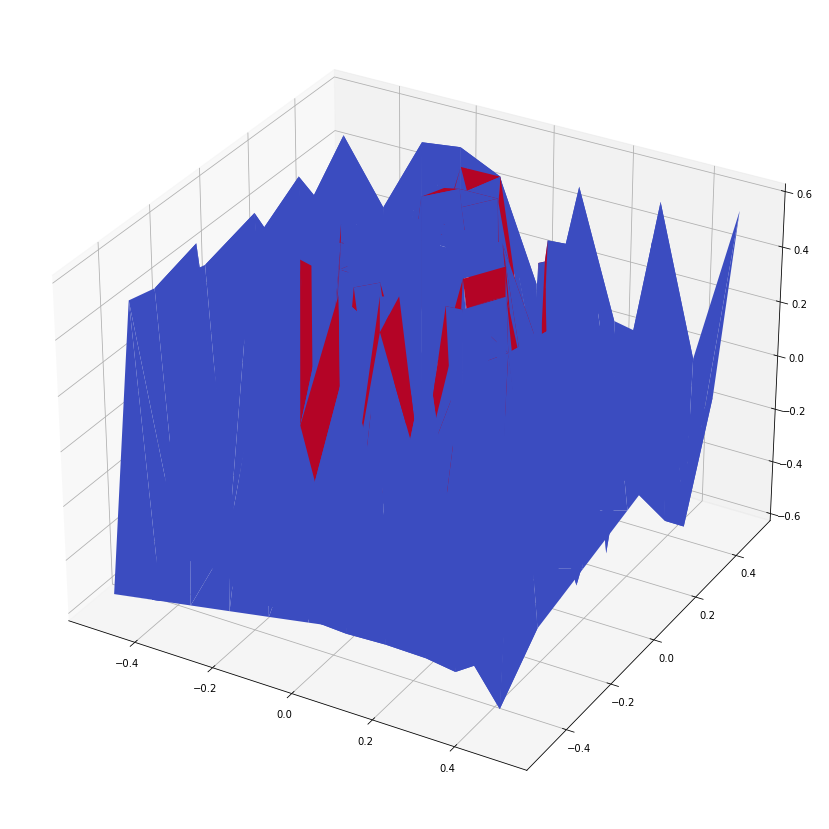

ValueError: operands could not be broadcast together with shapes (2216,) (208,) 

In [14]:
ddr.plot_solution(mesh, u, elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u,ref_sol))

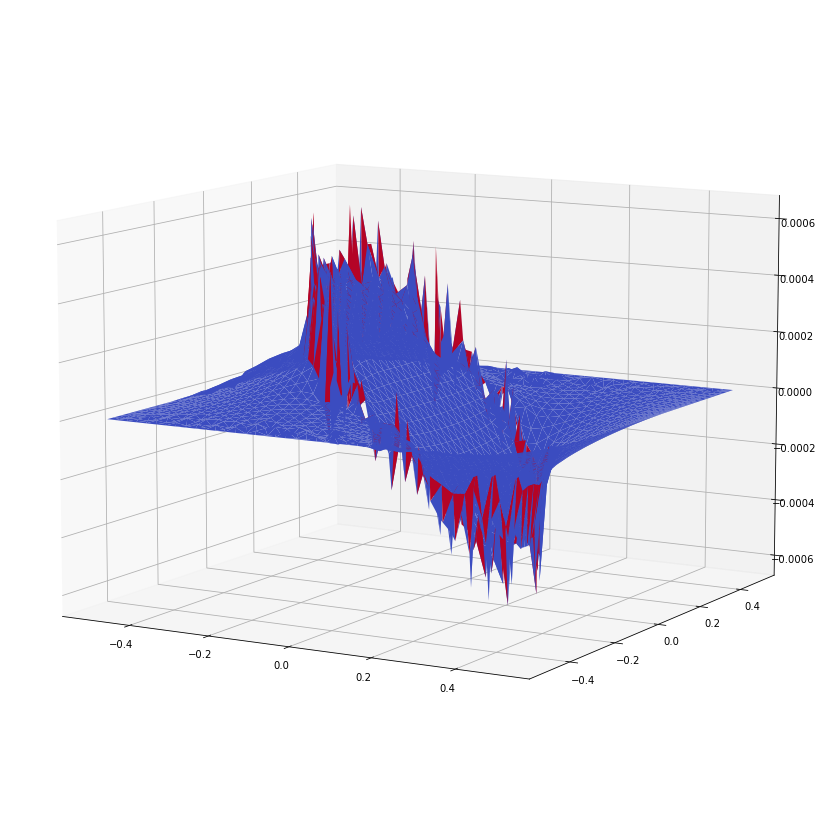

Error:  0.0


In [50]:
u_ref = np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)])
ddr.plot_solution(mesh, u-u_ref, elevation=10, azimuth=-60)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))

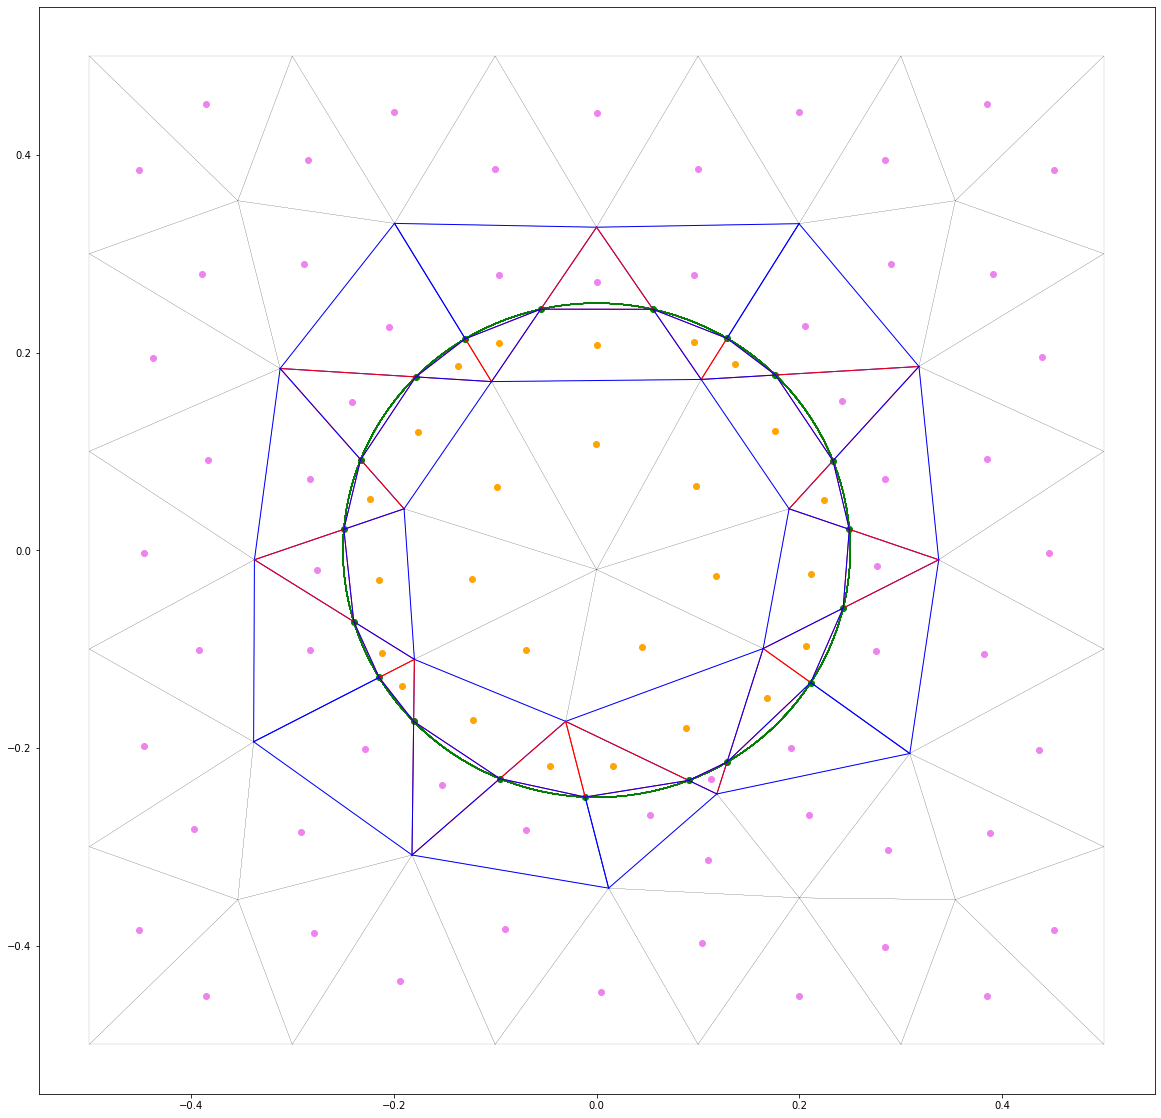

In [26]:
ddr.visualize_mesh(mesh,rho)

### Visualize Convergence 

[1.33653235 0.11377741 1.09231119]


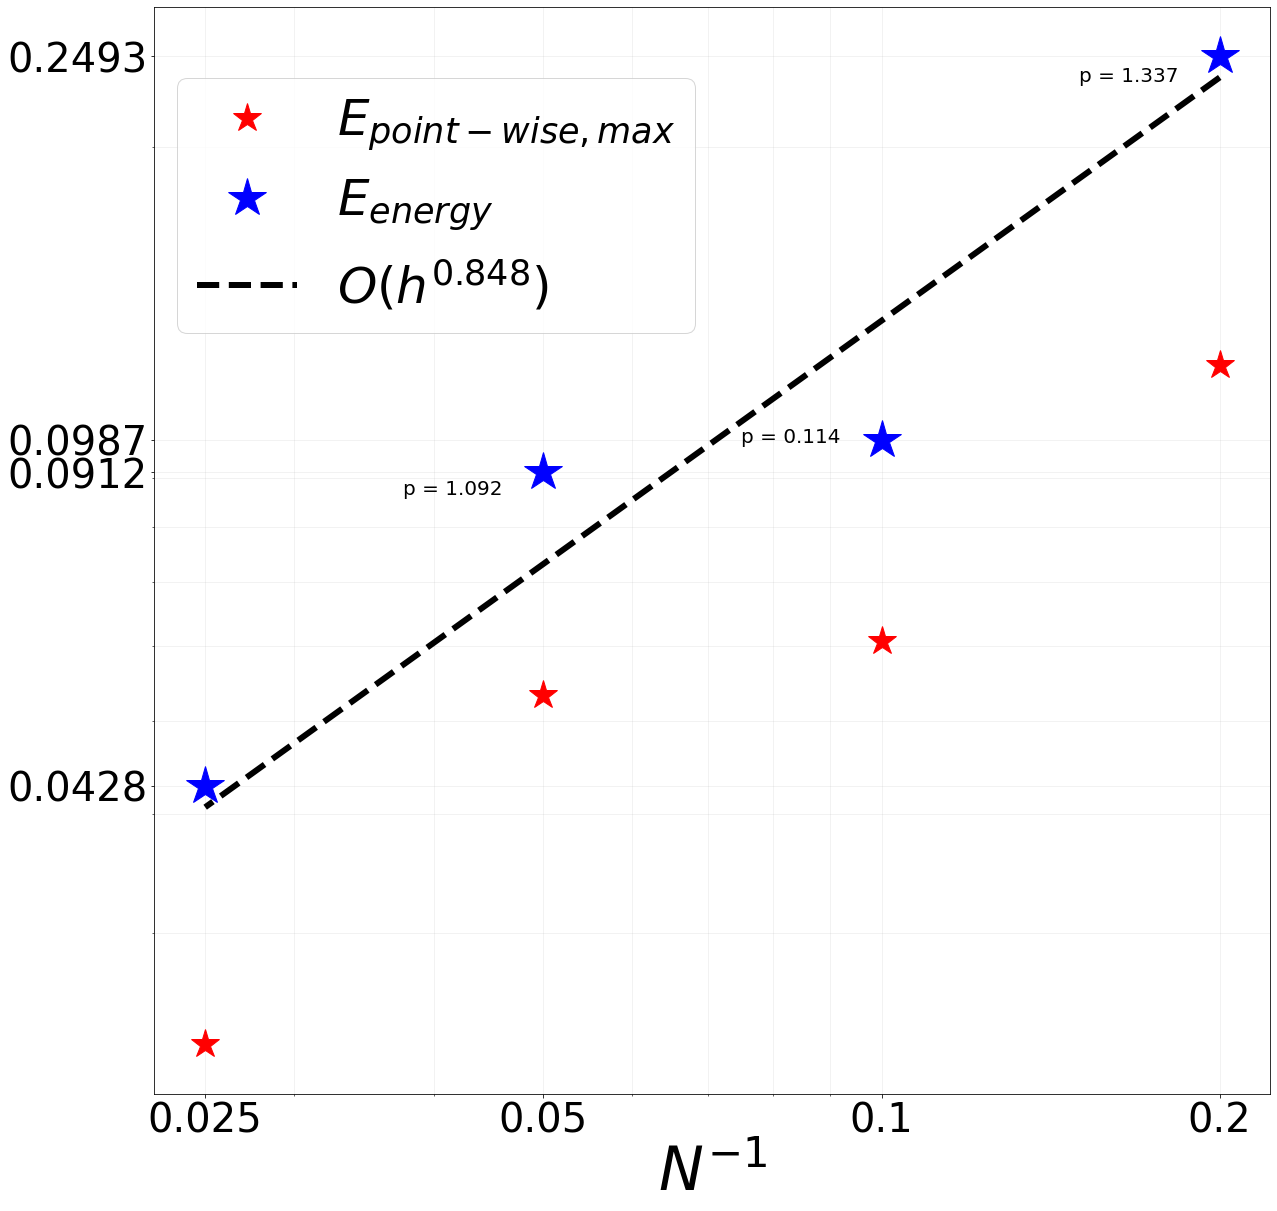

In [15]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = len(size_list)
fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

In [93]:
n = 3
ddr.plot_solution(Meshes[n], solutions[n], elevation=30, azimuth=90)
print ("Error: ", ddr.calc_L0_error(Meshes[n],solutions[n],ref_sol))

IndexError: list index out of range

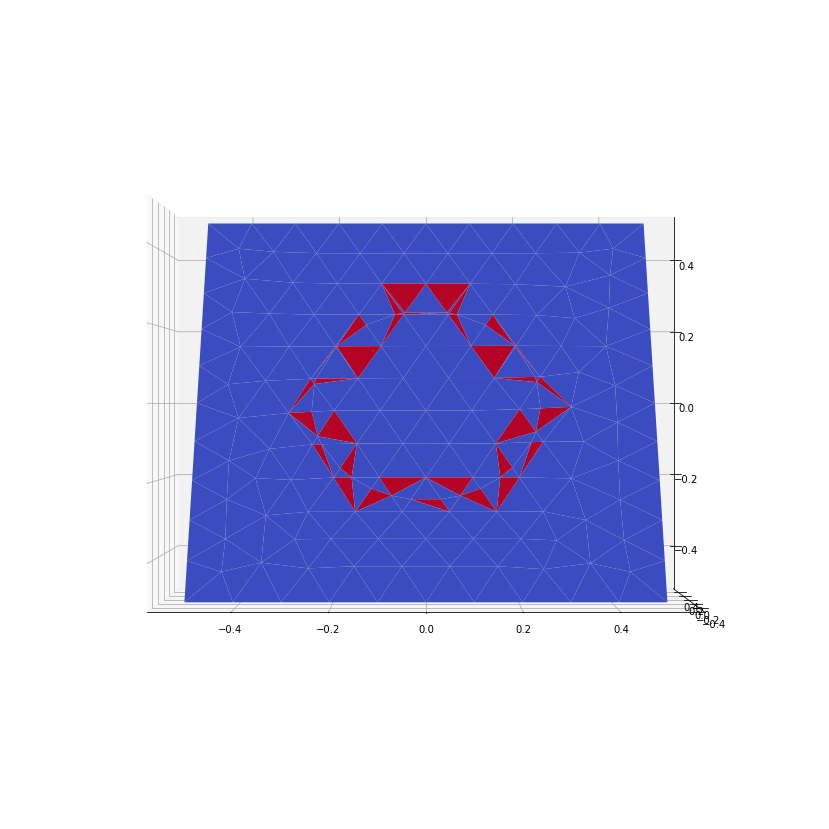

Error:  0.00014230847698259996


In [13]:
# solve for a given mesh 
meshname = "square_L1_N20"
#meshname = "/home/aspadotto/meshes/square"
[mesh, G, S, M_gamma, N_gamma, b_phi, A, b, u, err] = \
        ddr.solve_problem(meshname+".msh", meshname+".vtk", \
                          rho, ref_sol, sigma_in, sigma_ex, eta, phi_datum)

Check on Gradients

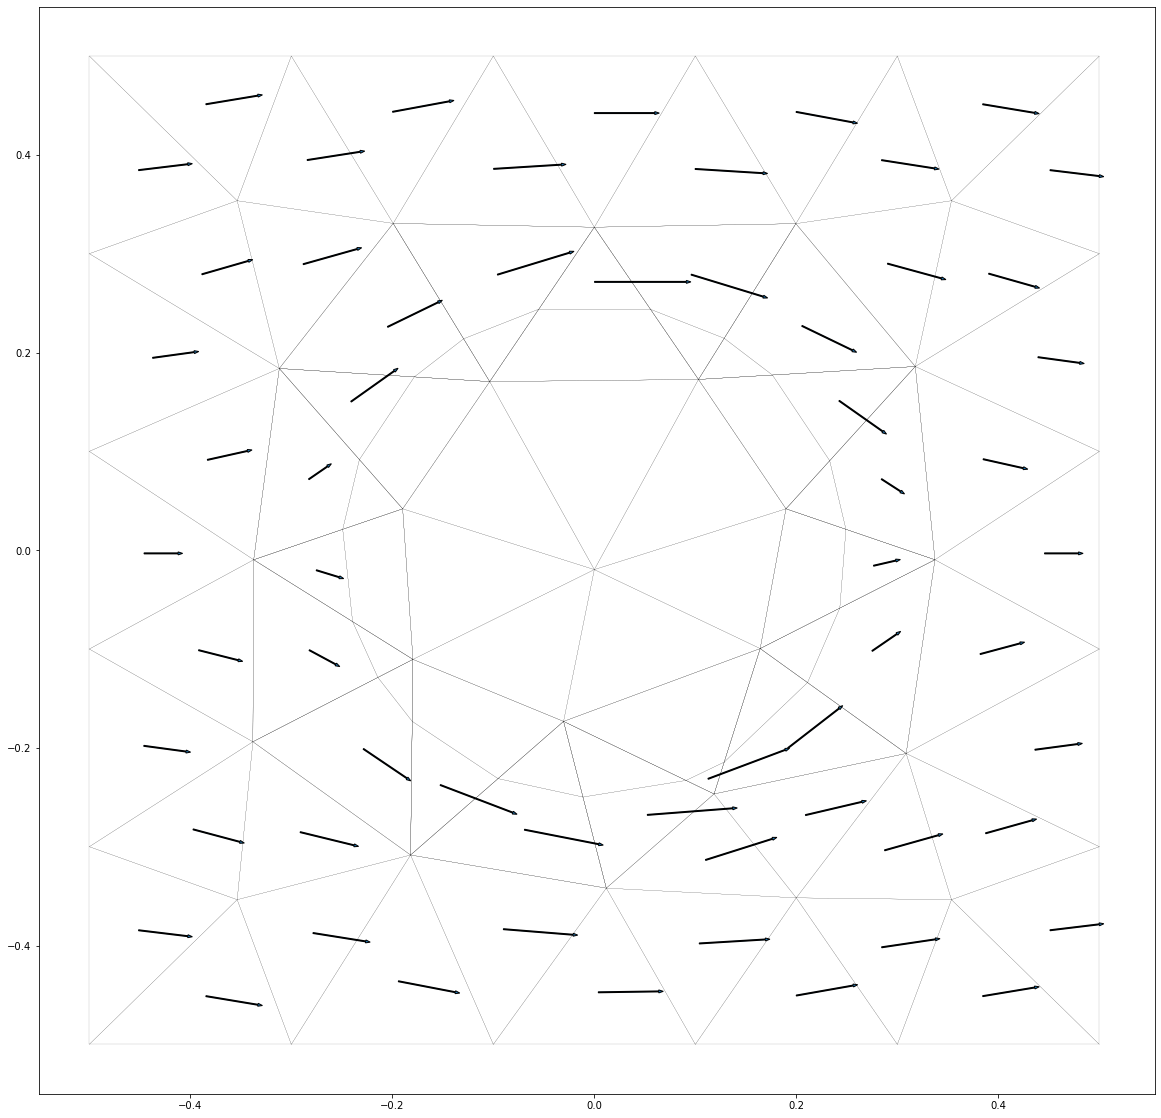

In [99]:
def visualize_gradient(mesh, u):
    fig, ax = plt.subplots(figsize=(20,20))
    for ifa in range(mesh.Nfaces):
        node_per_face =  np.count_nonzero(mesh.faces[ifa,:] != -1)
        nvert = node_per_face
        for ino in range(nvert):
            # draw edges
            p1 = mesh.coords[mesh.faces[ifa,ino],:]
            p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
            dx = p2-p1
            xx = [p1[0],p2[0]]
            yy = [p1[1],p2[1]]
            ax.plot(xx,yy,'k', linewidth=0.1)
        # arrow of gradient
        if (mesh.side_mask[ifa]==1):
            bary = ddr.barycenter(mesh, ifa)
            G = ddr.GR(mesh, ifa)
            u_F = np.zeros(node_per_face)
            for ino in range(node_per_face):
                dof = ddr.glob_idx(mesh, ifa, ino)
                u_F[ino] = u[dof]
            grad = np.dot(G, u_F)/20 #-----------------> this to show gradient of u_ref
            # grad = G[:, 3]/50          #-----------------> this to show gradient of test functions 
            ax.arrow(bary[0], bary[1], grad[0], grad[1])

visualize_gradient(mesh, u_ref)

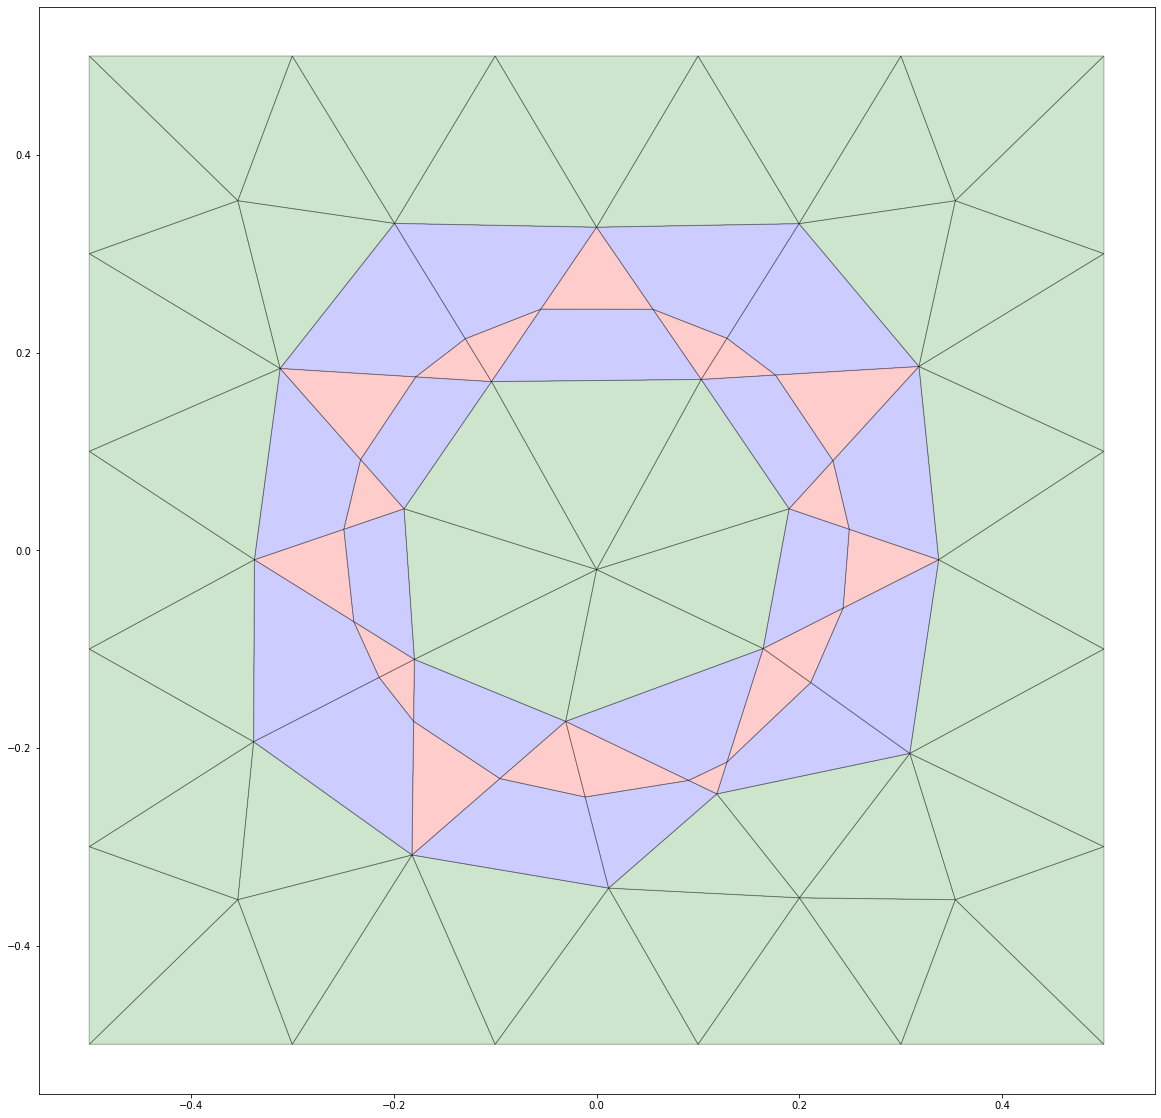

In [27]:
def check(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
                color = 'red'
            else:
                nvert = 4
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
                color = 'green'
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               verts.append(p1[0:2])
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)

n = 0
mesh = Meshes[n]
check(mesh)